In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

In [8]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier

In [9]:
df = pd.read_csv("Crop_recommendation.csv")


In [10]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [11]:
# remove extra spaces + lowercase everything
df.columns = df.columns.str.strip().str.lower()
df.columns


Index(['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [12]:
                
X = df[['N','P','K','temperature','humidity','ph','rainfall']]
y = df['label']     



KeyError: "['N', 'P', 'K'] not in index"

In [ ]:
print(y.head())


In [ ]:

target_col = df.columns[-1]   # last column ko target maan lo
print("Target column:", target_col)


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df=df.drop_duplicates()

In [15]:
df = pd.read_csv("Crop_recommendation.csv")

print(df.head())
print(df.columns)



    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [16]:
X = df[['N','P','K','temperature','humidity','ph','rainfall']]
y = df['label']

In [17]:
print(y.head())


0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object


In [64]:
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])


In [65]:
X = df.drop(target_col, axis=1)
y = df[target_col]


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [67]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [68]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))


Logistic Regression Accuracy: 0.9636363636363636


In [69]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.9931818181818182


In [70]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))


SVM Accuracy: 0.9681818181818181


In [71]:
lsvc_model = LinearSVC(max_iter=5000)
lsvc_model.fit(X_train, y_train)

lsvc_pred = lsvc_model.predict(X_test)
print("Linear SVC Accuracy:", accuracy_score(y_test, lsvc_pred))


Linear SVC Accuracy: 0.9613636363636363


In [72]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy: 0.9863636363636363


In [73]:
results = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "Linear SVC": accuracy_score(y_test, lsvc_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred)
}

for model, acc in results.items():
    print(model, ":", round(acc*100, 2), "%")


Logistic Regression : 96.36 %
Random Forest : 99.32 %
SVM : 96.82 %
Linear SVC : 96.14 %
Decision Tree : 98.64 %


In [74]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [75]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)


[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0 23  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

In [76]:

model_preds = {
    "Logistic Regression": (log_model, log_pred),
    "Random Forest": (rf_model, rf_pred),
    "SVM": (svm_model, svm_pred),
    "Linear SVC": (lsvc_model, lsvc_pred),
    "Decision Tree": (dt_model, dt_pred)
}


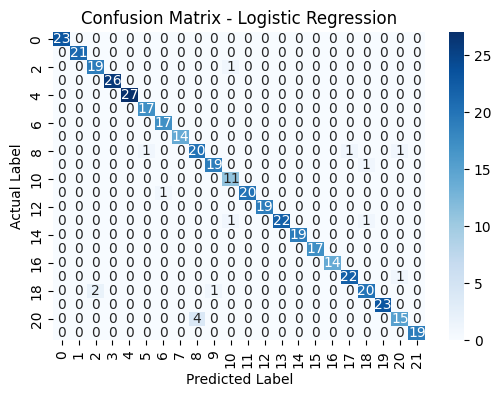

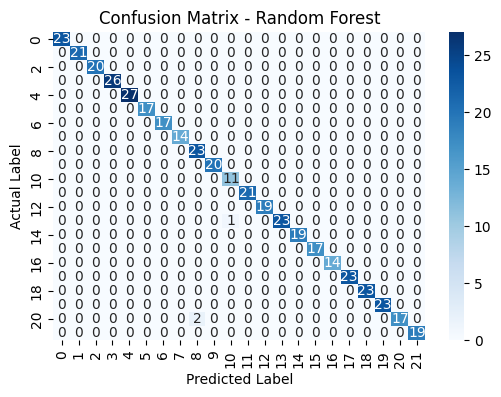

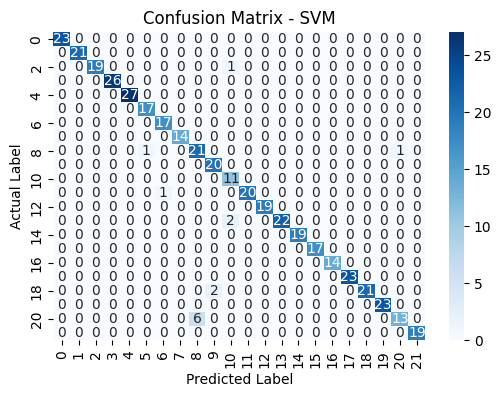

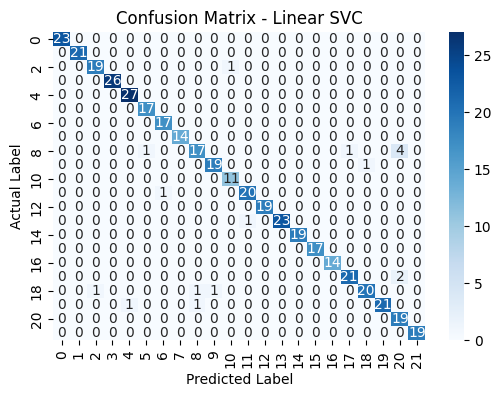

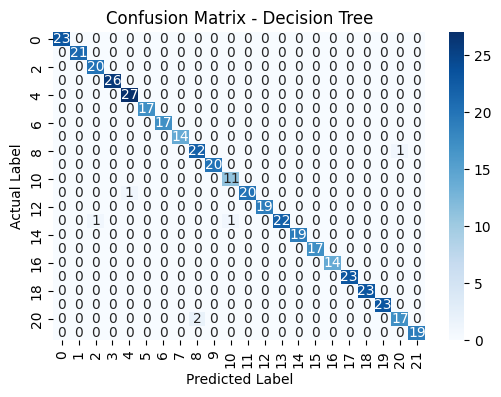

In [77]:
for model_name, (model, preds) in model_preds.items():
    
    cm = confusion_matrix(y_test, preds)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()


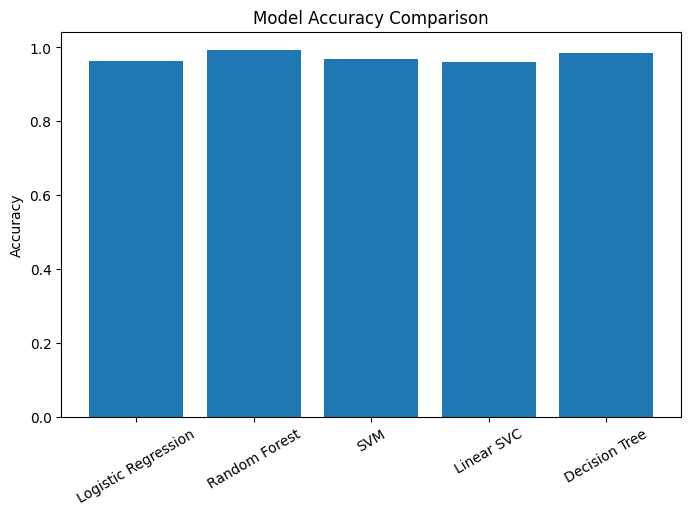

In [78]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


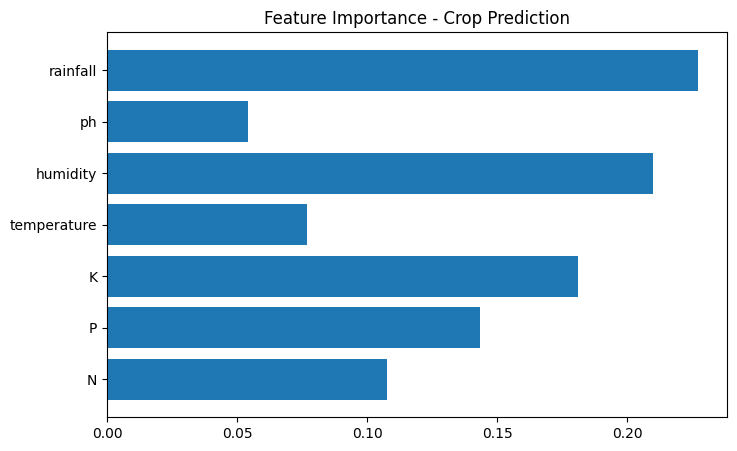

In [79]:
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance - Crop Prediction")
plt.show()


In [80]:
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(rf_model, X, y, cv=5)
print("CV Accuracy:", cv_score.mean())


CV Accuracy: 0.9945454545454545


In [81]:
import joblib

joblib.dump(rf_model, "crop_recommendation_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model, scaler & encoder saved successfully ✅")


Model, scaler & encoder saved successfully ✅


In [53]:

# Load saved files
model = joblib.load("crop_recommendation_model.pkl")
scaler = joblib.load("scaler.pkl")
encoder = joblib.load("label_encoder.pkl")
